In [ ]:
install.packages(c(
  "tidyverse",
  "readxl",
  "janitor",
  "lubridate",
  "skimr",
  "writexl",
  "scales"
))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘snakecase’




In [ ]:
library(tidyverse)
library(readxl)
library(janitor)
library(lubridate)
library(skimr)
library(writexl)
library(scales)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test



Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




In [ ]:
country_colors <- c(
  "Korea" = "#1F77B4",
  "Japan" = "#B02300",
  "Taiwan" = "#148A04"
)

gap_colors <- c(
  "Korea minus Japan" = "#D62728",
  "Korea minus Taiwan" = "#2CA02C"
)

# Korea PBR

In [ ]:
kospi_monthly <- read_csv("kospi_monthly_2010_2025.csv")

glimpse(kospi_monthly)

Rows: 192 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (5): close, per, pbr, dividend_yield, pct_change
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 192
Columns: 6
$ date           <date> 2010-01-31, 2010-02-28, 2010-03-31, 2010-04-30, 2010-0…
$ close          <dbl> 1602.43, 1594.58, 1692.85, 1741.56, 1641.25, 1698.29, 1…
$ per            <dbl> 23.64150, 22.75000, 23.79318, 23.51864, 14.77579, 15.22…
$ pbr            <dbl> 1.343000, 1.277895, 1.334091, 1.375000, 1.218421, 1.258…
$ dividend_yield <dbl> 1.173000, 1.231579, 1.176364, 1.145000, 1.353684, 1.307…
$ pct_change     <dbl> -0.23850000, -0.01736842, 0.27363636, 0.13272727, -0.30…


In [ ]:
kospi_monthly <- kospi_monthly %>%
  mutate(
    date = as.Date(date),
    year = year(date)
  )

In [ ]:
desc_monthly <- kospi_monthly %>%
  select(close, per, pbr, dividend_yield) %>%
  pivot_longer(
    cols = everything(),
    names_to = "variable",
    values_to = "value"
  ) %>%
  group_by(variable) %>%
  summarise(
    N = sum(!is.na(value)),
    Mean = mean(value, na.rm = TRUE),
    Median = median(value, na.rm = TRUE),
    `Std. Dev.` = sd(value, na.rm = TRUE),
    Min = min(value, na.rm = TRUE),
    Max = max(value, na.rm = TRUE),
    .groups = "drop"
  )

desc_monthly

variable,N,Mean,Median,Std. Dev.,Min,Max
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
close,192,2282.087187,2116.905000,441.6847544,1594.5800000,4214.170000
dividend_yield,192,1.588137,1.513463,0.3423773,1.0281818,2.496818
pbr,192,1.095278,1.111178,0.1616058,0.7254545,1.560952
per,192,15.358672,14.441126,4.4961775,9.5926316,32.763182


In [ ]:
theme_thesis <- function(base_size = 15) {
  theme_minimal(base_size = base_size) +
    theme(
      plot.title = element_text(face = "bold"),
      plot.subtitle = element_text(color = "black"),
      axis.title = element_text(face = "plain"),
      panel.grid.minor = element_blank(),
      panel.grid.major.x = element_blank()
    )
}

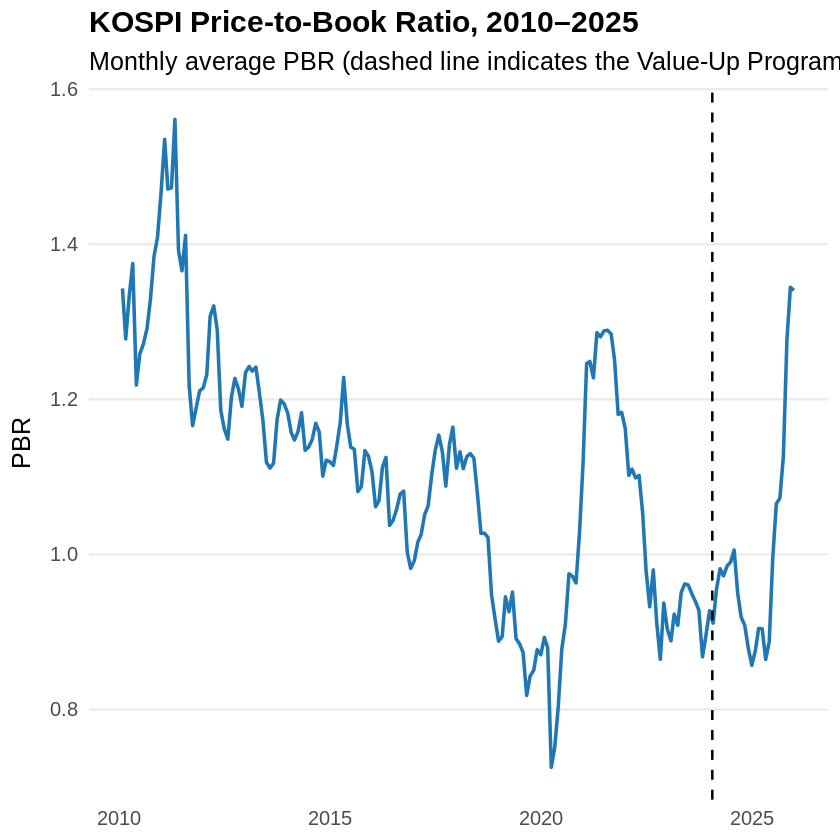

In [ ]:

ggplot(kospi_monthly, aes(x = date, y = pbr)) +
  geom_line(linewidth = 1, color = country_colors["Korea"]) +
  geom_vline(
    xintercept = as.Date("2024-01-24"),
    linetype = "dashed",
    linewidth = 0.7
  ) +
  labs(
    title = "KOSPI Price-to-Book Ratio, 2010–2025",
    subtitle = "Monthly average PBR (dashed line indicates the Value-Up Program announcement)",
    x = NULL,
    y = "PBR"
  ) +
  theme_thesis()

In [ ]:
ggsave(
  "/content/graphs/kospi_pbr_monthly_2010_2025.png",
  width = 12,
  height = 6,
  dpi = 300
)

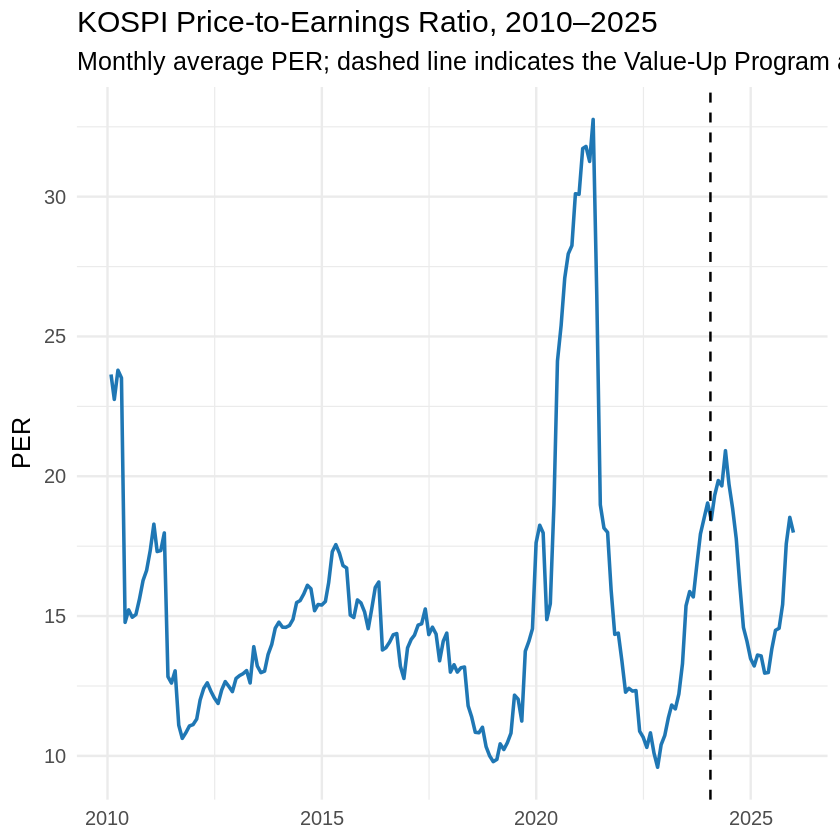

In [ ]:
ggplot(kospi_monthly, aes(x = date, y = per)) +
  geom_line(linewidth = 1, color = country_colors["Korea"]) +
  geom_vline(
    xintercept = as.Date("2024-01-24"),
    linetype = "dashed",
    linewidth = 0.7
  ) +
  labs(
    title = "KOSPI Price-to-Earnings Ratio, 2010–2025",
    subtitle = "Monthly average PER; dashed line indicates the Value-Up Program announcement",
    x = NULL,
    y = "PER"
  ) +
  theme_minimal(base_size = 15)

In [ ]:
ggsave(
  "/content/graphs/kospi_per_monthly_2010_2025.png",
  width = 12,
  height = 6,
  dpi = 300
)

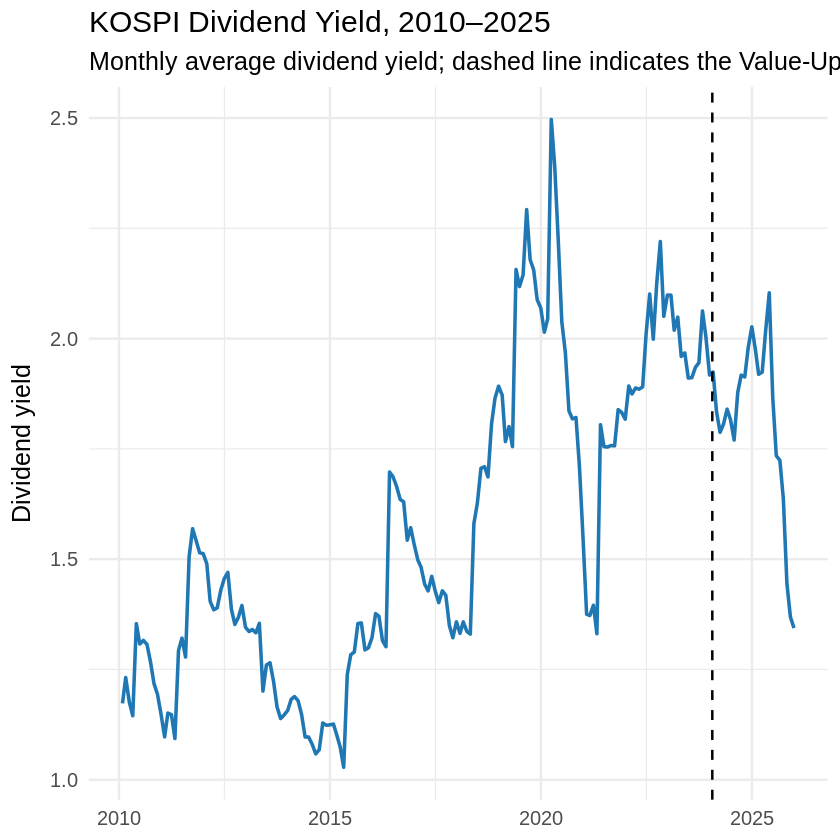

In [ ]:
ggplot(kospi_monthly, aes(x = date, y = dividend_yield)) +
  geom_line(linewidth = 1, color = country_colors["Korea"]) +
  geom_vline(
    xintercept = as.Date("2024-01-24"),
    linetype = "dashed",
    linewidth = 0.7
  ) +
  labs(
    title = "KOSPI Dividend Yield, 2010–2025",
    subtitle = "Monthly average dividend yield; dashed line indicates the Value-Up Program announcement",
    x = NULL,
    y = "Dividend yield"
  ) +
  theme_minimal(base_size = 15)

In [ ]:
ggsave(
  "/content/graphs/kospi_dividend_yield_monthly_2010_2025.png",
  width = 12,
  height = 6,
  dpi = 300
)

In [ ]:
kospi_yearly <- read_csv("kospi_yearly_2010_2025.csv")

glimpse(kospi_yearly)

Rows: 16 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (9): year, mean_close, year_end_close, mean_per, median_per, mean_pbr, m...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 16
Columns: 9
$ year                <dbl> 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 20…
$ mean_close          <dbl> 1764.994, 1983.420, 1930.373, 1960.500, 1982.158, …
$ year_end_close      <dbl> 2051.00, 1825.74, 1997.05, 2011.34, 1915.59, 1961.…
$ mean_per            <dbl> 18.29669, 13.64069, 12.25839, 13.45433, 15.29980, …
$ median_per          <dbl> 16.450, 12.705, 12.280, 13.200, 15.370, 15.840, 14…
$ mean_pbr            <dbl> 1.3317131, 1.3493548, 1.2255242, 1.1829150, 1.1447…
$ median_pbr          <dbl> 1.330, 1.380, 1.220, 1.190, 1.150, 1.130, 1.060, 1…
$ mean_dividend_yield <dbl> 1.235020, 1.337379, 1.406573, 1.244332, 1.123347, …
$ observations        <dbl> 251, 248, 248, 247, 245, 248, 246, 243, 244, 246, …


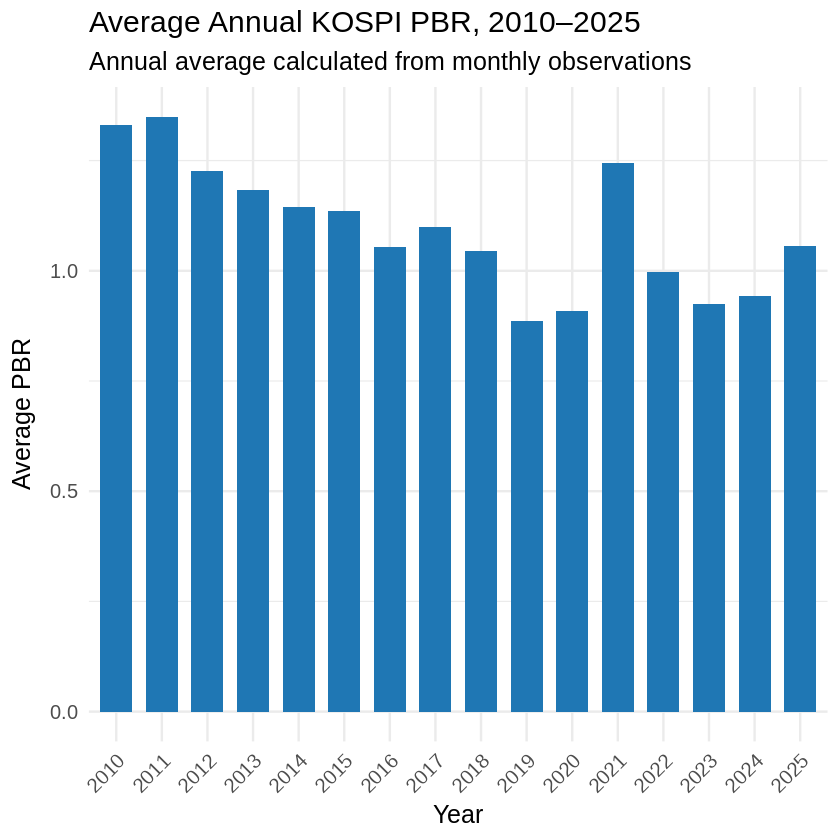

In [ ]:
ggplot(kospi_yearly, aes(x = factor(year), y = mean_pbr)) +
  geom_col(width = 0.7, fill = country_colors["Korea"]) +
  labs(
    title = "Average Annual KOSPI PBR, 2010–2025",
    subtitle = "Annual average calculated from monthly observations",
    x = "Year",
    y = "Average PBR"
  ) +
  theme_minimal(base_size = 15) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

In [ ]:
ggsave(
  "/content/graphs/kospi_yearly_average_pbr_2010_2025.png",
  width = 12,
  height = 6,
  dpi = 300
)

# Japan

In [ ]:
japan <- read_csv("/content/japan_per_pbr_2010_2025_clean.csv")

glimpse(japan)

Rows: 192 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): country, market_section, accounting_basis, aggregation_method
dbl  (7): year, month, no_companies, per, pbr, eps, bps
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 192
Columns: 12
$ date               <date> 2010-01-01, 2010-02-01, 2010-03-01, 2010-04-01, 20…
$ year               <dbl> 2010, 2010, 2010, 2010, 2010, 2010, 2010, 2010, 201…
$ month              <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, …
$ country            <chr> "Japan", "Japan", "Japan", "Japan", "Japan", "Japan…
$ market_section     <chr> "TSE First Section", "TSE First Section", "TSE Firs…
$ accounting_basis   <chr> "Consolidated", "Consolidated", "Consolidated", "Co…
$ aggregation_method <chr> "Average", "Average", "Average", "Average", "Averag…
$ no_companies       <dbl> 1672, 1670, 1658, 1661, 1660, 1668, 1667, 1665, 165…
$ per                <dbl> NA, NA, NA, NA, NA, 33.6, 33.6, 30.5, 31.5, 30.0, 3…
$ pbr                <dbl> 0.9, 0.9, 1.0, 1.0, 0.9, 0.8, 0.8, 0.8, 0.8, 0.8, 0…
$ eps                <dbl> -1.71, -1.87, -1.74, -1.82, -1.82, 7.06, 6.97, 7.22…
$ bps                <dbl> 280.08, 280.13, 277.94, 276.10, 276.64, 287.08, 285…


In [ ]:
japan <- japan %>%
  mutate(
    date = as.Date(date),
    country = "Japan"
  )

In [ ]:
japan_plot <- japan %>%
  select(date, country, per, pbr, market_section)

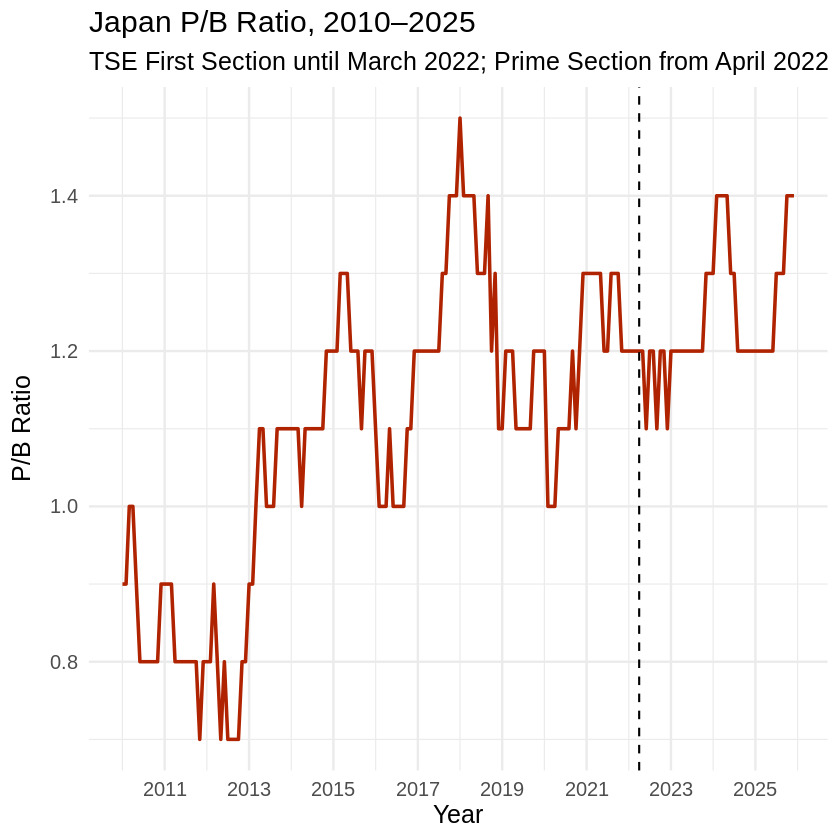

In [ ]:
ggplot(japan_plot, aes(x = date, y = pbr)) +
  geom_line(linewidth = 1, color = country_colors["Japan"]) +
  geom_vline(
    xintercept = as.Date("2022-04-01"),
    linetype = "dashed",
    linewidth = 0.6
  ) +
  labs(
    title = "Japan P/B Ratio, 2010–2025",
    subtitle = "TSE First Section until March 2022; Prime Section from April 2022",
    x = "Year",
    y = "P/B Ratio",
    #caption = "Source: Japan Exchange Group / TSE monthly valuation data."
  ) +
  scale_x_date(date_breaks = "2 years", date_labels = "%Y") +
  theme_minimal(base_size = 15)

In [ ]:
ggsave(
  filename = "/content/graphs/japan_pbr_2010_2025.png",
  width = 12,
  height = 6,
  dpi = 300
)

Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_line()`).”


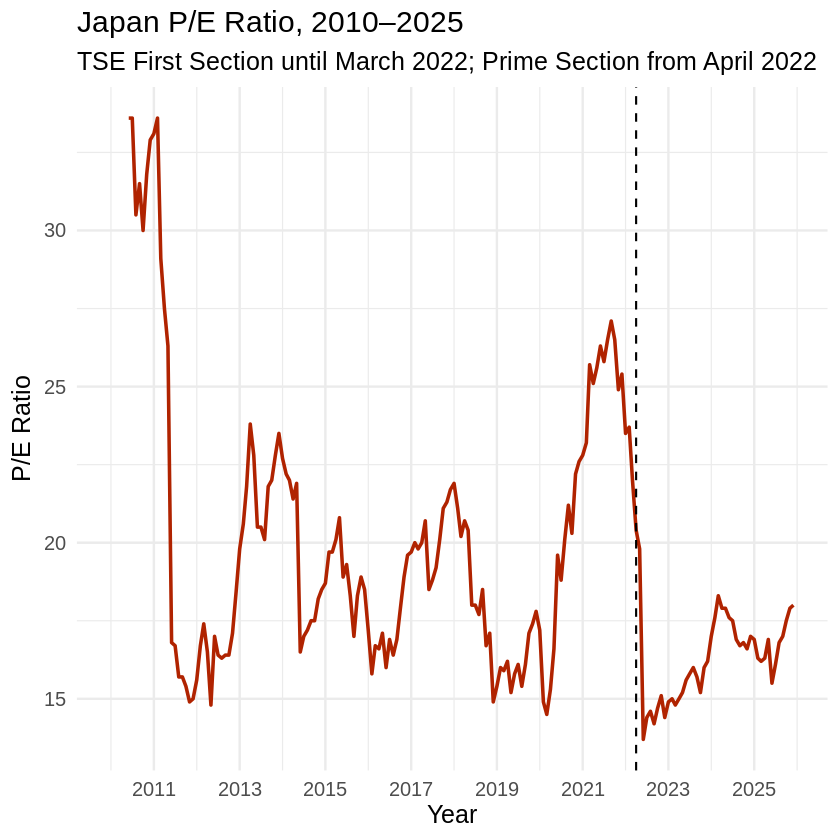

In [ ]:
ggplot(japan_plot, aes(x = date, y = per)) +
  geom_line(linewidth = 1, color = country_colors["Japan"]) +
  geom_vline(
    xintercept = as.Date("2022-04-01"),
    linetype = "dashed",
    linewidth = 0.6
  ) +
  labs(
    title = "Japan P/E Ratio, 2010–2025",
    subtitle = "TSE First Section until March 2022; Prime Section from April 2022",
    x = "Year",
    y = "P/E Ratio",
    #caption = "Source: Japan Exchange Group / TSE monthly valuation data."
  ) +
  scale_x_date(date_breaks = "2 years", date_labels = "%Y") +
  theme_minimal(base_size = 15)

In [ ]:
ggsave(
  filename = "/content/graphs/japan_per_2010_2025.png",
  width = 12,
  height = 6,
  dpi = 300
)

Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_line()`).”


# Taiwan

In [ ]:
taiwan <- read_csv("/content/taiwan_monthly_per_pbr_2010_2025.csv")

glimpse(taiwan)

Rows: 192 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (1): country
dbl  (10): observations, valid_per, valid_pbr, valid_dividend_yield, mean_pe...
date  (2): date, date_used

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 192
Columns: 13
$ date                  <date> 2010-01-01, 2010-02-01, 2010-03-01, 2010-04-01,…
$ date_used             <date> 2010-01-28, 2010-02-26, 2010-03-31, 2010-04-30,…
$ observations          <dbl> 739, 741, 738, 740, 740, 740, 742, 741, 742, 741…
$ valid_per             <dbl> 478, 479, 504, 590, 606, 607, 609, 634, 638, 643…
$ valid_pbr             <dbl> 739, 741, 738, 740, 738, 739, 741, 738, 739, 739…
$ valid_dividend_yield  <dbl> 739, 741, 738, 740, 740, 740, 742, 741, 742, 741…
$ mean_per              <dbl> 55.90036, 53.38015, 55.33274, 34.53290, 24.13117…
$ median_per            <dbl> 20.320, 19.720, 21.015, 16.760, 14.695, 14.580, …
$ mean_pbr              <dbl> 1.904452, 1.841363, 2.001328, 2.159189, 1.912249…
$ median_pbr            <dbl> 1.450, 1.410, 1.575, 1.500, 1.350, 1.350, 1.480,…
$ mean_dividend_yield   <dbl> 2.358647, 2.424211, 2.212547, 3.096554, 3.394122…
$ median_dividend_yield <dbl> 1.860, 1.920, 1.710, 2.940, 3.415, 3.480, 3.240,…
$ country         

In [ ]:
taiwan <- taiwan %>%
  mutate(
    date = as.Date(date),
    country = "Taiwan"
  )

In [ ]:
taiwan_plot <- taiwan %>%
  select(
    date,
    country,
    mean_per,
    median_per,
    mean_pbr,
    median_pbr,
    mean_dividend_yield,
    median_dividend_yield
  )

In [ ]:
taiwan_pbr_long <- taiwan_plot %>%
  select(date, median_pbr, mean_pbr) %>%
  pivot_longer(
    cols = c(median_pbr, mean_pbr),
    names_to = "measure",
    values_to = "pbr"
  ) %>%
  mutate(
    measure = recode(
      measure,
      "median_pbr" = "Median P/B",
      "mean_pbr" = "Mean P/B"
    )
  )

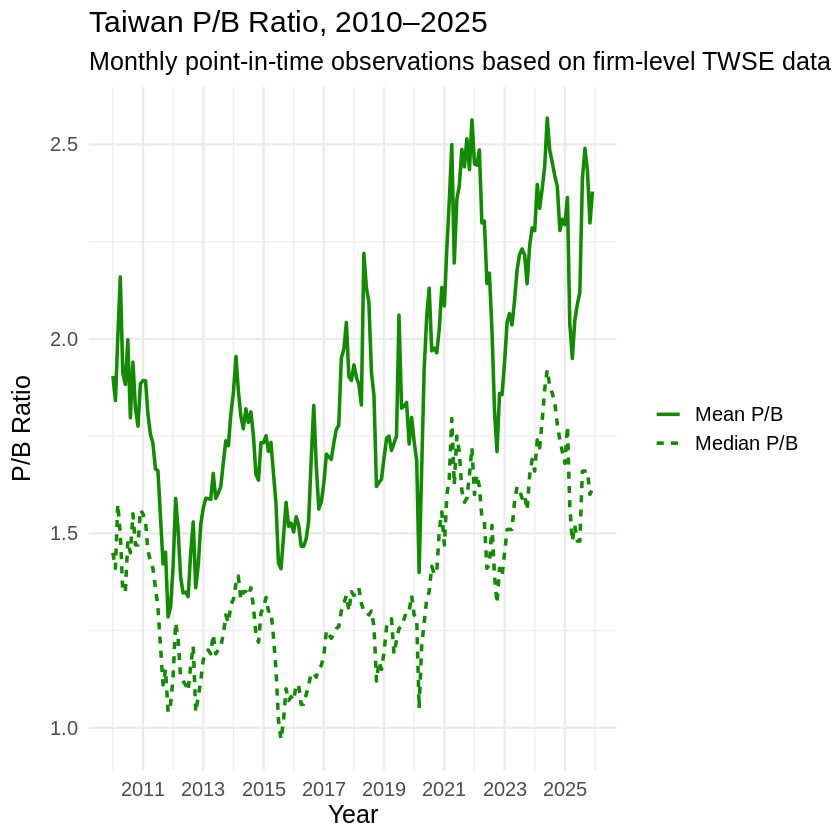

In [ ]:
ggplot(taiwan_pbr_long, aes(x = date, y = pbr, linetype = measure)) +
  geom_line(linewidth = 1, color = country_colors["Taiwan"]) +
  labs(
    title = "Taiwan P/B Ratio, 2010–2025",
    subtitle = "Monthly point-in-time observations based on firm-level TWSE data",
    x = "Year",
    y = "P/B Ratio",
    linetype = NULL,
    #caption = "Source: Taiwan Stock Exchange daily P/E, dividend yield, and P/B files."
  ) +
  scale_x_date(date_breaks = "2 years", date_labels = "%Y") +
  theme_minimal(base_size = 15)

In [ ]:
ggsave(
  filename = "graphs/taiwan_pbr_2010_2025.png",
  width = 12,
  height = 6,
  dpi = 300
)

In [ ]:
taiwan_per_long <- taiwan_plot %>%
  select(date, median_per, mean_per) %>%
  pivot_longer(
    cols = c(median_per, mean_per),
    names_to = "measure",
    values_to = "per"
  ) %>%
  mutate(
    measure = recode(
      measure,
      "median_per" = "Median P/E",
      "mean_per" = "Mean P/E"
    )
  )

In [ ]:
ggplot(taiwan_per_long, aes(x = date, y = per, linetype = measure)) +
  geom_line(linewidth = 1, color = country_colors["Taiwan"]) +
  labs(
    title = "Taiwan P/E Ratio, 2010–2025",
    subtitle = "Monthly point-in-time observations based on firm-level TWSE data",
    x = "Year",
    y = "P/E Ratio",
    linetype = NULL,
    #caption = "Source: Taiwan Stock Exchange daily P/E, dividend yield, and P/B files."
  ) +
  scale_x_date(date_breaks = "2 years", date_labels = "%Y") +
  theme_minimal(base_size = 15)

ERROR: Error in ggplot(taiwan_per_long, aes(x = date, y = per, linetype = measure)): could not find function "ggplot"


In [ ]:
ggsave(
  filename = "graphs/taiwan_per_2010_2025.png",
  width = 12,
  height = 6,
  dpi = 300
)

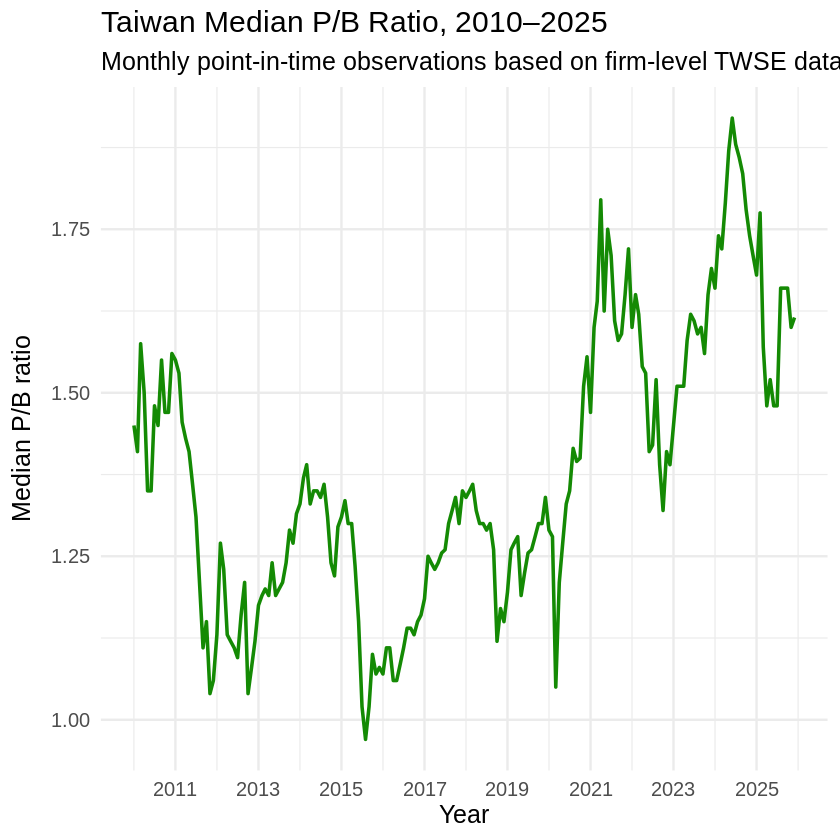

In [ ]:
ggplot(taiwan_plot, aes(x = date, y = median_pbr)) +
  geom_line(linewidth = 1, color = country_colors["Taiwan"]) +
  labs(
    title = "Taiwan Median P/B Ratio, 2010–2025",
    subtitle = "Monthly point-in-time observations based on firm-level TWSE data",
    x = "Year",
    y = "Median P/B ratio",
    #caption = "Source: TWSE."
  ) +
  scale_x_date(date_breaks = "2 years", date_labels = "%Y") +
  theme_minimal(base_size = 15)

In [ ]:
ggsave(
  filename = "/content/taiwan_pbr_2010_2025.png",
  width = 12,
  height = 6,
  dpi = 300
)

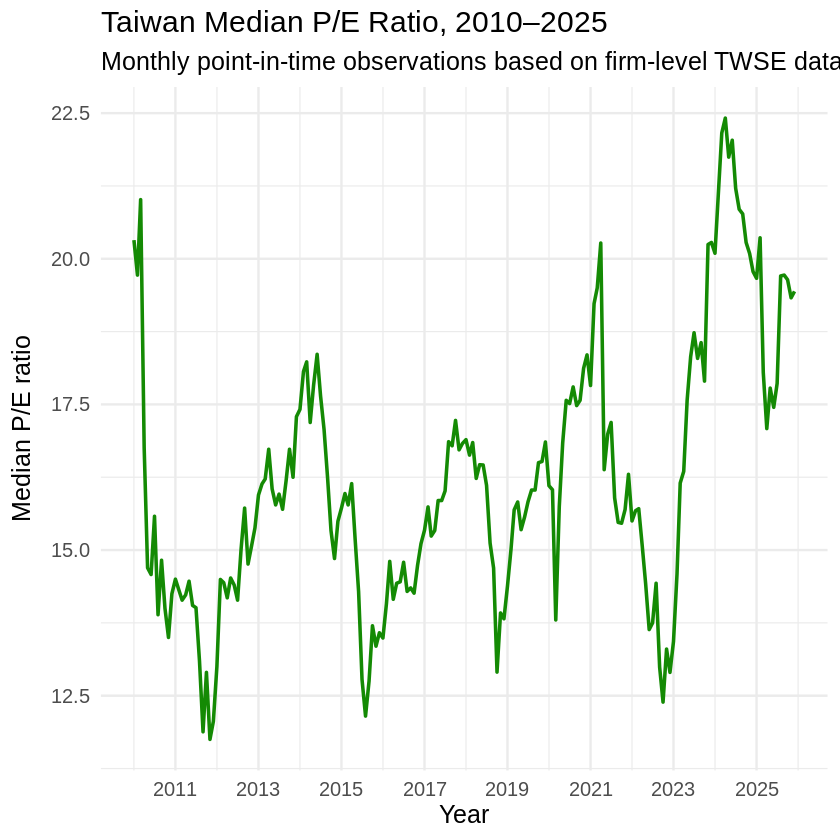

In [ ]:
ggplot(taiwan_plot, aes(x = date, y = median_per)) +
  geom_line(linewidth = 1, color = country_colors["Taiwan"]) +
  labs(
    title = "Taiwan Median P/E Ratio, 2010–2025",
    subtitle = "Monthly point-in-time observations based on firm-level TWSE data",
    x = "Year",
    y = "Median P/E ratio",
    #caption = "Source: TWSE."
  ) +
  scale_x_date(date_breaks = "2 years", date_labels = "%Y") +
  theme_minimal(base_size = 15)

In [ ]:
ggsave(
  filename = "/content/taiwan_per_2010_2025.png",
  width = 12,
  height = 6,
  dpi = 300
)

# Comparison

In [ ]:
korea <- read_csv("/content/kospi_monthly_2010_2025.csv")

glimpse(korea)

Rows: 192 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (5): close, per, pbr, dividend_yield, pct_change
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 192
Columns: 6
$ date           <date> 2010-01-31, 2010-02-28, 2010-03-31, 2010-04-30, 2010-0…
$ close          <dbl> 1602.43, 1594.58, 1692.85, 1741.56, 1641.25, 1698.29, 1…
$ per            <dbl> 23.64150, 22.75000, 23.79318, 23.51864, 14.77579, 15.22…
$ pbr            <dbl> 1.343000, 1.277895, 1.334091, 1.375000, 1.218421, 1.258…
$ dividend_yield <dbl> 1.173000, 1.231579, 1.176364, 1.145000, 1.353684, 1.307…
$ pct_change     <dbl> -0.23850000, -0.01736842, 0.27363636, 0.13272727, -0.30…


In [ ]:
korea <- korea %>%
  mutate(
    date = as.Date(date),
    country = "Korea"
  )

In [ ]:
korea_plot <- korea %>%
  select(date, country, per, pbr)

In [ ]:
japan_comparison <- japan_plot %>%
  select(date, country, per, pbr)

In [ ]:
taiwan_comparison <- taiwan_plot %>%
  transmute(
    date = date,
    country = "Taiwan",
    per = median_per,
    pbr = median_pbr
  )

In [ ]:
comparison <- bind_rows(
  korea_plot,
  japan_comparison,
  taiwan_comparison
) %>%
  filter(date >= as.Date("2010-01-01"),
         date <= as.Date("2025-12-31"))

In [ ]:
comparison %>%
  group_by(country) %>%
  summarise(
    start_date = min(date, na.rm = TRUE),
    end_date = max(date, na.rm = TRUE),
    observations = n(),
    mean_pbr = mean(pbr, na.rm = TRUE),
    median_pbr = median(pbr, na.rm = TRUE)
  )

country,start_date,end_date,observations,mean_pbr,median_pbr
<chr>,<date>,<date>,<int>,<dbl>,<dbl>
Japan,2010-01-01,2025-12-01,192,1.121875,1.200000
Korea,2010-01-31,2025-12-31,192,1.095278,1.111178
Taiwan,2010-01-01,2025-12-01,192,1.372812,1.332500


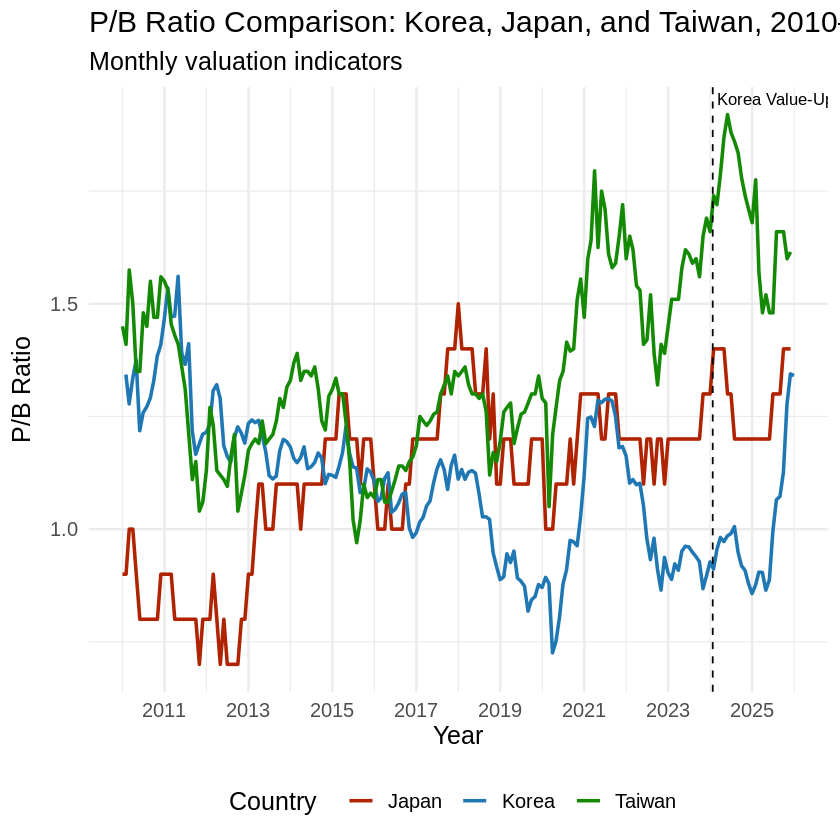

In [ ]:
ggplot(comparison, aes(x = date, y = pbr, color = country)) +
  geom_line(linewidth = 1, na.rm = TRUE) +
  geom_vline(
    xintercept = as.Date("2024-01-24"),
    linetype = "dashed",
    linewidth = 0.5
  ) +
  annotate(
    "text",
    x = as.Date("2024-03-01"),
    y = Inf,
    label = "Korea Value-Up announcement",
    vjust = 1.5,
    hjust = 0,
    size = 3.5
  ) +
  labs(
    title = "P/B Ratio Comparison: Korea, Japan, and Taiwan, 2010–2025",
    subtitle = "Monthly valuation indicators",
    x = "Year",
    y = "P/B Ratio",
    color = "Country",
    #caption = "Sources: KRX, JPX/TSE, TWSE. Taiwan uses median firm-level P/B."
  ) +
  scale_x_date(date_breaks = "2 years", date_labels = "%Y") +
  scale_color_manual(values = country_colors) +
  theme_minimal(base_size = 15) +
  theme(
    legend.position = "bottom"
  )

In [ ]:
ggsave(
  filename = "graphs/pbr_comparison_korea_japan_taiwan_2010_2025.png",
  width = 12,
  height = 6.5,
  dpi = 300
)

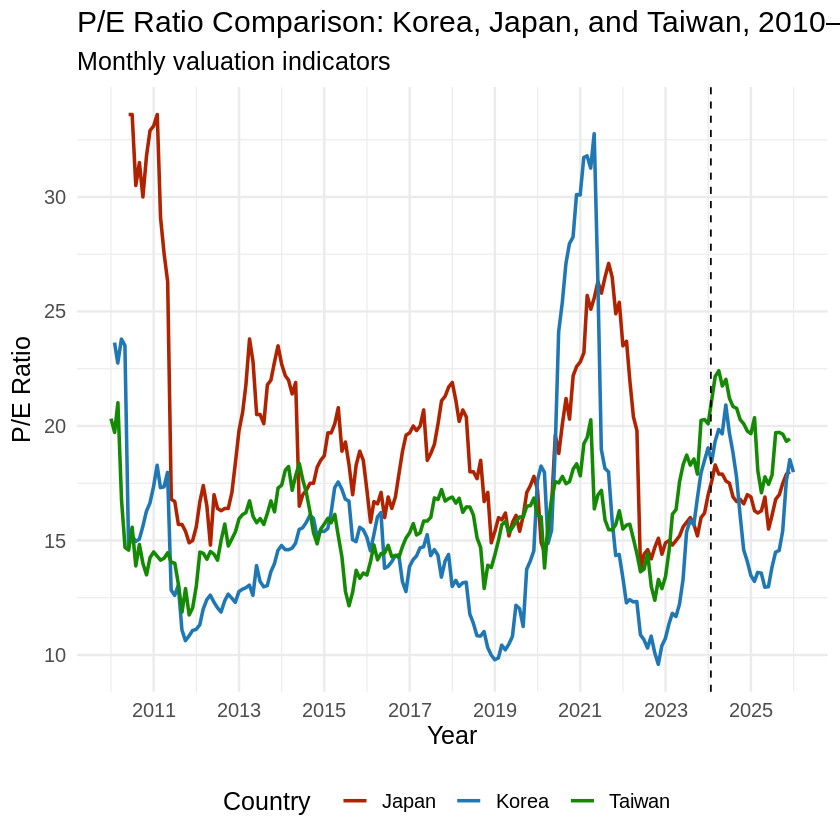

In [ ]:
ggplot(comparison, aes(x = date, y = per, color = country)) +
  geom_line(linewidth = 1, na.rm = TRUE) +
  geom_vline(
    xintercept = as.Date("2024-01-24"),
    linetype = "dashed",
    linewidth = 0.5
  ) +
  labs(
    title = "P/E Ratio Comparison: Korea, Japan, and Taiwan, 2010–2025",
    subtitle = "Monthly valuation indicators",
    x = "Year",
    y = "P/E Ratio",
    color = "Country",
    #caption = "Sources: KRX, JPX/TSE, TWSE. Taiwan uses median firm-level P/E."
  ) +
  scale_x_date(date_breaks = "2 years", date_labels = "%Y") +
  scale_color_manual(values = country_colors) +
  theme_minimal(base_size = 15) +
  theme(
    legend.position = "bottom"
  )

In [ ]:
ggsave(
  filename = "graphs/per_comparison_korea_japan_taiwan_2010_2025.png",
  width = 11,
  height = 6.5,
  dpi = 300
)

In [ ]:
comparison_yearly <- comparison %>%
  mutate(year = year(date)) %>%
  group_by(country, year) %>%
  summarise(
    mean_pbr = mean(pbr, na.rm = TRUE),
    median_pbr = median(pbr, na.rm = TRUE),
    mean_per = mean(per, na.rm = TRUE),
    median_per = median(per, na.rm = TRUE),
    .groups = "drop"
  )

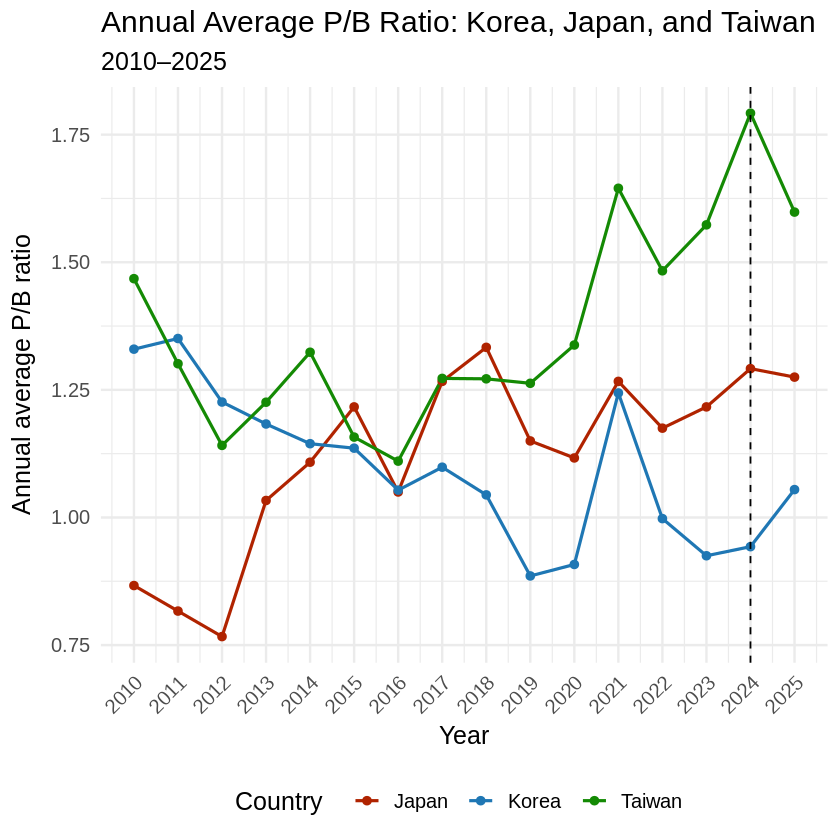

In [ ]:
ggplot(comparison_yearly, aes(x = year, y = mean_pbr, color = country)) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 1.8) +
  geom_vline(
    xintercept = 2024,
    linetype = "dashed",
    linewidth = 0.5
  ) +
  labs(
    title = "Annual Average P/B Ratio: Korea, Japan, and Taiwan",
    subtitle = "2010–2025",
    x = "Year",
    y = "Annual average P/B ratio",
    color = "Country",
    #caption = "Sources: KRX, JPX/TSE, TWSE."
  ) +
  scale_x_continuous(breaks = seq(2010, 2025, 1)) +
  scale_color_manual(values = country_colors) +
  theme_minimal(base_size = 15) +
  theme(
    legend.position = "bottom",
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

In [ ]:
ggsave(
  filename = "graphs/annual_pbr_comparison_korea_japan_taiwan_2010_2025.png",
  width = 12,
  height = 6.5,
  dpi = 300
)

In [ ]:
country_average_pbr <- comparison %>%
  group_by(country) %>%
  summarise(
    average_pbr = mean(pbr, na.rm = TRUE),
    median_pbr = median(pbr, na.rm = TRUE),
    .groups = "drop"
  )

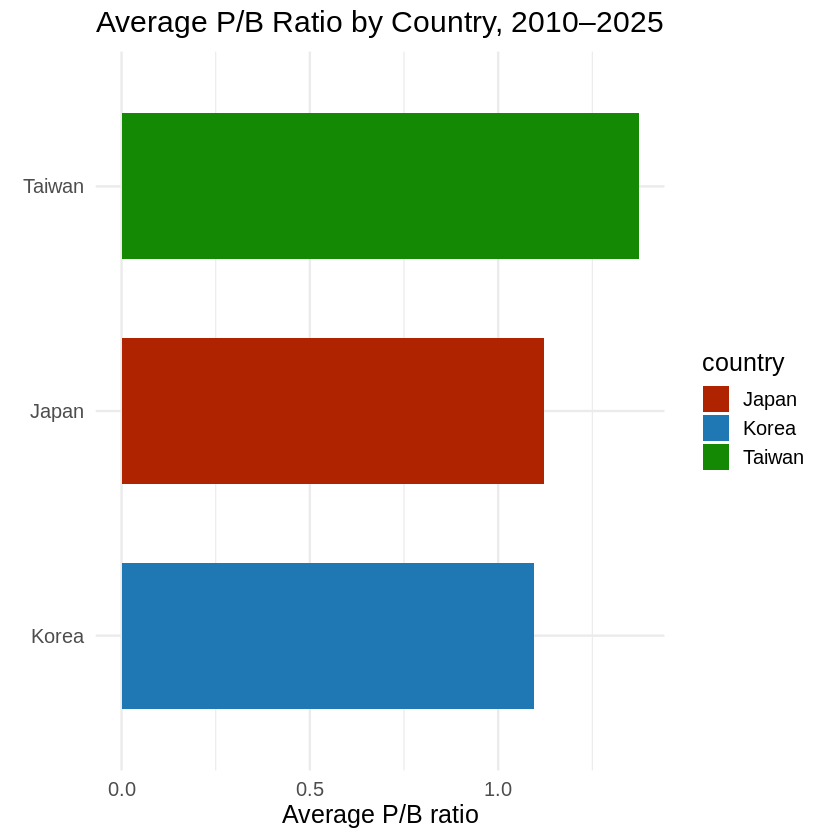

In [ ]:
ggplot(country_average_pbr, aes(x = reorder(country, average_pbr), y = average_pbr, fill = country)) +
  geom_col(width = 0.65) +
  scale_fill_manual(values = country_colors) +
  coord_flip() +
  labs(
    title = "Average P/B Ratio by Country, 2010–2025",
    x = NULL,
    y = "Average P/B ratio",
    #caption = "Sources: KRX, JPX/TSE, TWSE."
  ) +
  theme_minimal(base_size = 15)

In [ ]:
ggsave(
  filename = "graphs/average_pbr_by_country_2010_2025.png",
  width = 12,
  height = 5,
  dpi = 300
)

In [ ]:
library(tidyverse)
library(lubridate)

pbr_wide <- comparison %>%
  mutate(month = floor_date(date, "month")) %>%
  select(month, country, pbr) %>%
  group_by(month, country) %>%
  summarise(
    pbr = mean(pbr, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  pivot_wider(
    names_from = country,
    values_from = pbr
  )

head(pbr_wide)

month,Japan,Korea,Taiwan
<date>,<dbl>,<dbl>,<dbl>
2010-01-01,0.9,1.343000,1.450
2010-02-01,0.9,1.277895,1.410
2010-03-01,1.0,1.334091,1.575
2010-04-01,1.0,1.375000,1.500
2010-05-01,0.9,1.218421,1.350
2010-06-01,0.8,1.258571,1.350


In [ ]:
pbr_wide <- pbr_wide %>%
  mutate(
    korea_minus_japan = Korea - Japan,
    korea_minus_taiwan = Korea - Taiwan
  )

In [ ]:
pbr_gap_long <- pbr_wide %>%
  select(month, korea_minus_japan, korea_minus_taiwan) %>%
  pivot_longer(
    cols = c(korea_minus_japan, korea_minus_taiwan),
    names_to = "gap",
    values_to = "value"
  ) %>%
  mutate(
    gap = recode(
      gap,
      "korea_minus_japan" = "Korea minus Japan",
      "korea_minus_taiwan" = "Korea minus Taiwan"
    )
  )

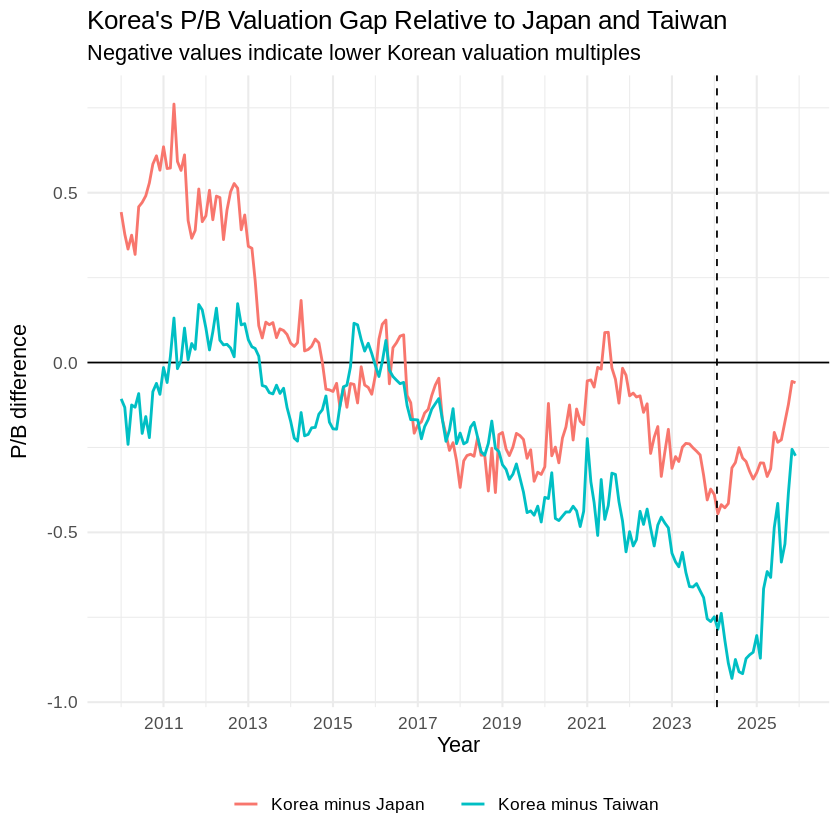

In [ ]:
ggplot(pbr_gap_long, aes(x = month, y = value, color = gap)) +
  geom_hline(yintercept = 0, linewidth = 0.5) +
  geom_line(linewidth = 0.8, na.rm = TRUE) +
  geom_vline(
    xintercept = as.Date("2024-01-24"),
    linetype = "dashed",
    linewidth = 0.5
  ) +
  labs(
    title = "Korea's P/B Valuation Gap Relative to Japan and Taiwan",
    subtitle = "Negative values indicate lower Korean valuation multiples",
    x = "Year",
    y = "P/B difference",
    color = NULL,
    #caption = "Sources: KRX, JPX/TSE, TWSE."
  ) +
  scale_x_date(date_breaks = "2 years", date_labels = "%Y") +
  theme_minimal(base_size = 13) +
  theme(
    legend.position = "bottom"
  )

In [ ]:
ggsave(
  filename = "graphs/korea_pbr_gap_japan_taiwan_2010_2025.png",
  width = 11,
  height = 6.5,
  dpi = 300
)

# Investors

In [ ]:
library(tidyverse)
library(scales)

dir.create("graphs", showWarnings = FALSE)

In [ ]:
trading_main <- read_csv("trading_investor_2010_2025_main_groups.csv")
institutional_detail <- read_csv("trading_investor_2010_2025_institutional_detail.csv")
trading_wide <- read_csv("trading_investor_2010_2025_wide_net_buying.csv")

Rows: 80 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): investor_type, source_file, investor_group, investor_group_clean, ...
dbl (11): volume_sell, volume_buy, volume_net_buying, value_sell, value_buy,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 112 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): investor_type, source_file, investor_group
dbl (7): volume_sell, volume_buy, volume_net_buying, value_sell, value_buy, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 16 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (6): year, domestic_institutions, foreigner

In [ ]:
glimpse(trading_main)
glimpse(institutional_detail)
glimpse(trading_wide)

Rows: 80
Columns: 16
$ investor_type           <chr> "Foreigners", "Individuals", "Other corporatio…
$ volume_sell             <dbl> 6084217, 80985446, 1077531, 185732, 7262781, 6…
$ volume_buy              <dbl> 6282120, 81157235, 906984, 172723, 7076647, 60…
$ volume_net_buying       <dbl> 197902, 171789, -170548, -13009, -186135, -131…
$ value_sell              <dbl> 273756968, 772747422, 26473034, 2486824, 33509…
$ value_buy               <dbl> 295330075, 767363640, 22957292, 2323379, 32258…
$ value_net_buying        <dbl> 21573107, -5383782, -3515742, -163445, -125101…
$ year                    <dbl> 2010, 2010, 2010, 2010, 2010, 2011, 2011, 2011…
$ source_file             <chr> "Trading_investor_2010.xlsx", "Trading_investo…
$ investor_group          <chr> "Foreigners", "Individuals", "Other corporatio…
$ investor_group_clean    <chr> "Foreigners", "Individuals", "Other corporatio…
$ value_total_trading     <dbl> 569087043, 1540111062, 49430326, 4810203, 6576…
$ volume_total_trad

In [ ]:
investor_colors <- c(
  "Domestic institutions" = "#1F77B4",  # blue
  "Foreigners" = "#D62728",             # red
  "Individuals" = "#2CA02C",            # green
  "Other corporations" = "#9467BD",      # purple
  "Other foreigners" = "#FF7F0E"         # orange
)

In [ ]:
institution_colors <- c(
  "Financial investment" = "#1F77B4",
  "Insurance" = "#FF7F0E",
  "Investment trust" = "#2CA02C",
  "Private equity funds" = "#D62728",
  "Bank" = "#9467BD",
  "Other finances" = "#8C564B",
  "Government pension funds, etc." = "#E377C2"
)

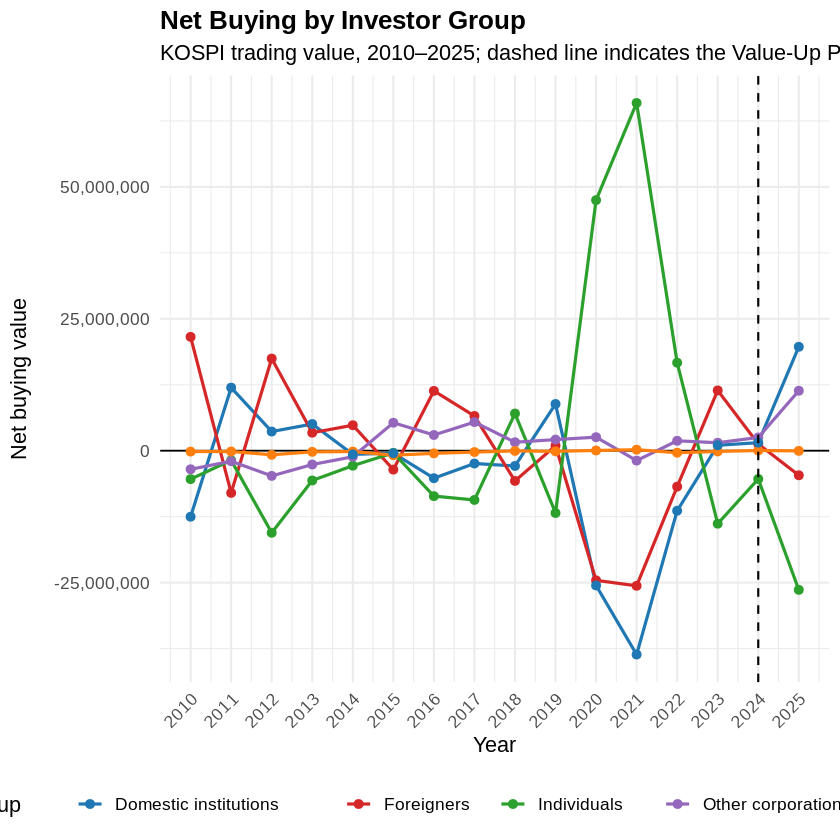

In [ ]:
ggplot(trading_main, aes(x = year, y = value_net_buying, color = investor_group_clean)) +
  geom_hline(yintercept = 0, linewidth = 0.5, color = "black") +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2) +
  geom_vline(
    xintercept = 2024,
    linetype = "dashed",
    linewidth = 0.6,
    color = "black"
  ) +
  scale_color_manual(values = investor_colors) +
  scale_y_continuous(labels = comma) +
  scale_x_continuous(breaks = seq(2010, 2025, 1)) +
  labs(
    title = "Net Buying by Investor Group",
    subtitle = "KOSPI trading value, 2010–2025; dashed line indicates the Value-Up Program period",
    x = "Year",
    y = "Net buying value",
    color = "Investor group",
    #caption = "Source: KRX investor trading data."
  ) +
  theme_minimal(base_size = 13, base_family = "sans") +
  theme(
    legend.position = "bottom",
    plot.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.caption = element_text(hjust = 0)
  )

In [ ]:
ggsave(
  filename = "graphs/investor_group_net_buying_2010_2025.png",
  width = 12,
  height = 7,
  dpi = 300
)

In [ ]:
institutions_foreigners <- trading_main %>%
  filter(investor_group_clean %in% c("Domestic institutions", "Foreigners"))

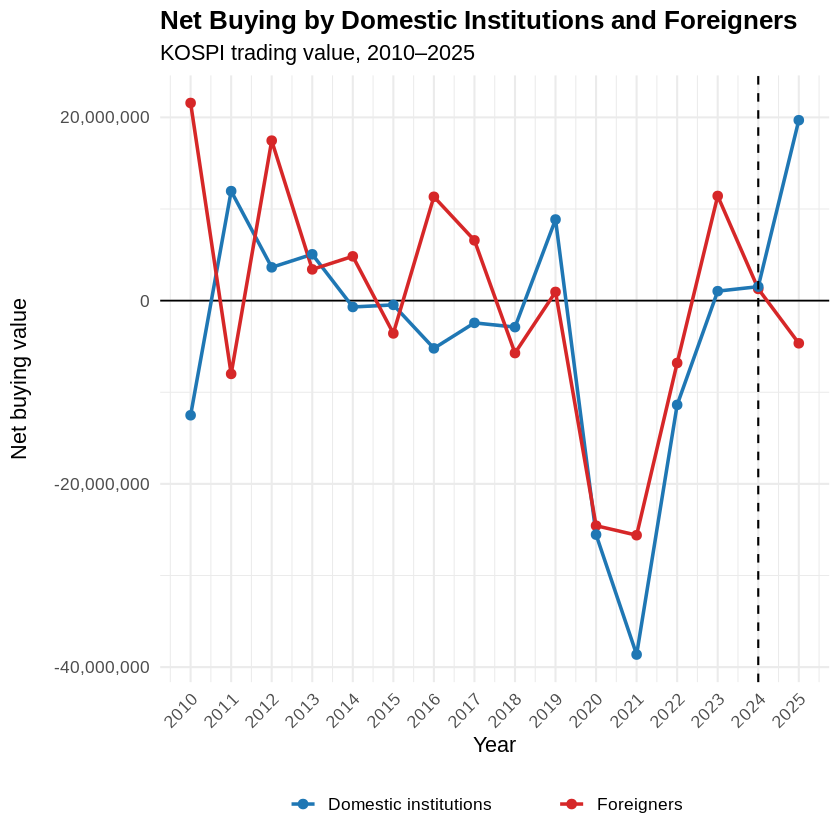

In [ ]:
ggplot(institutions_foreigners, aes(x = year, y = value_net_buying, color = investor_group_clean)) +
  geom_hline(yintercept = 0, linewidth = 0.5, color = "black") +
  geom_line(linewidth = 1) +
  geom_point(size = 2.2) +
  geom_vline(
    xintercept = 2024,
    linetype = "dashed",
    linewidth = 0.6,
    color = "black"
  ) +
  scale_color_manual(values = investor_colors) +
  scale_y_continuous(labels = comma) +
  scale_x_continuous(breaks = seq(2010, 2025, 1)) +
  labs(
    title = "Net Buying by Domestic Institutions and Foreigners",
    subtitle = "KOSPI trading value, 2010–2025",
    x = "Year",
    y = "Net buying value",
    color = NULL,
    #caption = "Source: KRX investor trading data."
  ) +
  theme_minimal(base_size = 13, base_family = "sans") +
  theme(
    legend.position = "bottom",
    plot.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.caption = element_text(hjust = 0)
  )

In [ ]:
ggsave(
  filename = "graphs/domestic_institutions_foreigners_net_buying_2010_2025.png",
  width = 12,
  height = 7,
  dpi = 300
)

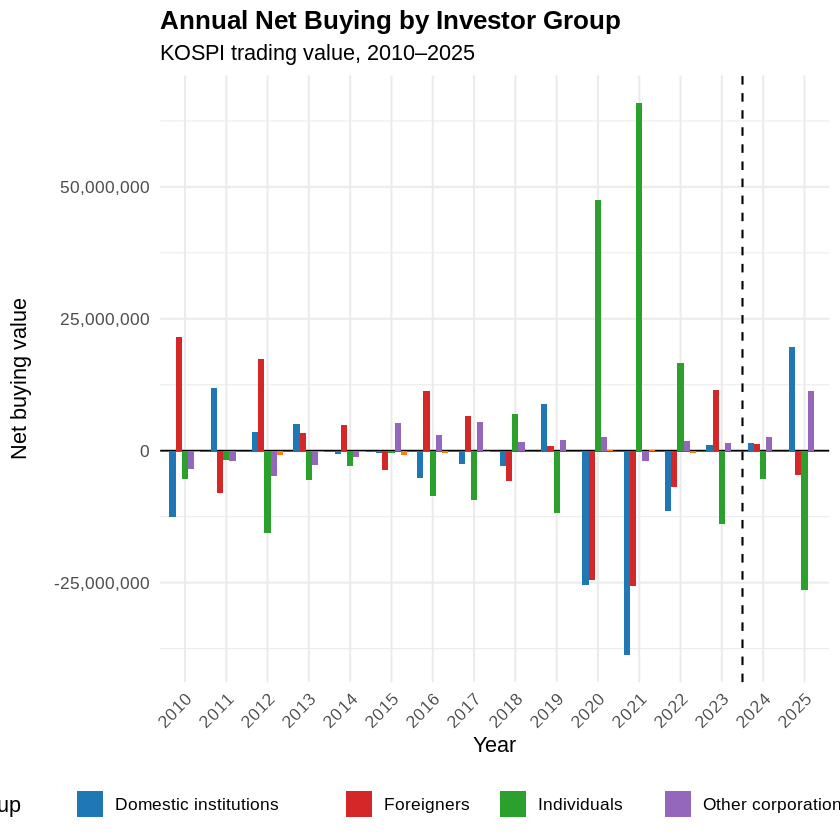

In [ ]:
ggplot(trading_main, aes(x = factor(year), y = value_net_buying, fill = investor_group_clean)) +
  geom_hline(yintercept = 0, linewidth = 0.5, color = "black") +
  geom_col(position = "dodge", width = 0.75) +
  geom_vline(
    xintercept = which(sort(unique(trading_main$year)) == 2024) - 0.5,
    linetype = "dashed",
    linewidth = 0.6,
    color = "black"
  ) +
  scale_fill_manual(values = investor_colors) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Annual Net Buying by Investor Group",
    subtitle = "KOSPI trading value, 2010–2025",
    x = "Year",
    y = "Net buying value",
    fill = "Investor group",
    #caption = "Source: KRX investor trading data."
  ) +
  theme_minimal(base_size = 13, base_family = "sans") +
  theme(
    legend.position = "bottom",
    plot.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.caption = element_text(hjust = 0)
  )

In [ ]:
ggsave(
  filename = "graphs/annual_net_buying_by_investor_group_bar_2010_2025.png",
  width = 13,
  height = 7,
  dpi = 300
)

In [ ]:
domestic_institutions <- trading_main %>%
  filter(investor_group_clean == "Domestic institutions")

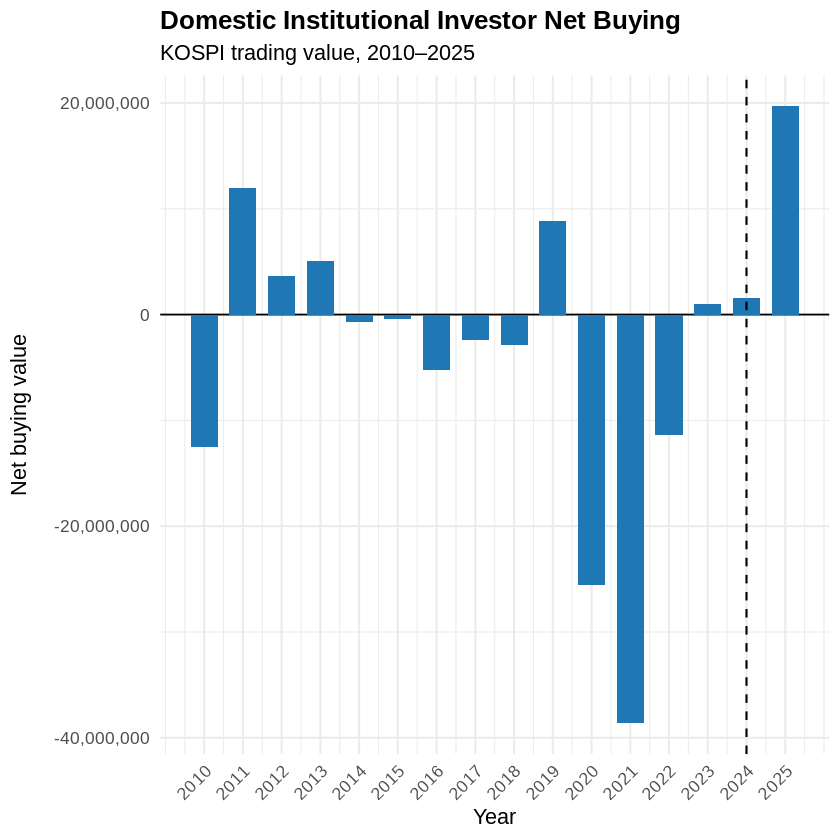

In [ ]:
ggplot(domestic_institutions, aes(x = year, y = value_net_buying)) +
  geom_hline(yintercept = 0, linewidth = 0.5, color = "black") +
  geom_col(fill = investor_colors["Domestic institutions"], width = 0.7) +
  geom_vline(
    xintercept = 2024,
    linetype = "dashed",
    linewidth = 0.6,
    color = "black"
  ) +
  scale_y_continuous(labels = comma) +
  scale_x_continuous(breaks = seq(2010, 2025, 1)) +
  labs(
    title = "Domestic Institutional Investor Net Buying",
    subtitle = "KOSPI trading value, 2010–2025",
    x = "Year",
    y = "Net buying value",
    #caption = "Source: KRX investor trading data."
  ) +
  theme_minimal(base_size = 13, base_family = "sans") +
  theme(
    plot.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.caption = element_text(hjust = 0)
  )

In [ ]:
ggsave(
  filename = "graphs/domestic_institutional_net_buying_2010_2025.png",
  width = 11,
  height = 6.5,
  dpi = 300
)

In [ ]:
foreigners <- trading_main %>%
  filter(investor_group_clean == "Foreigners")

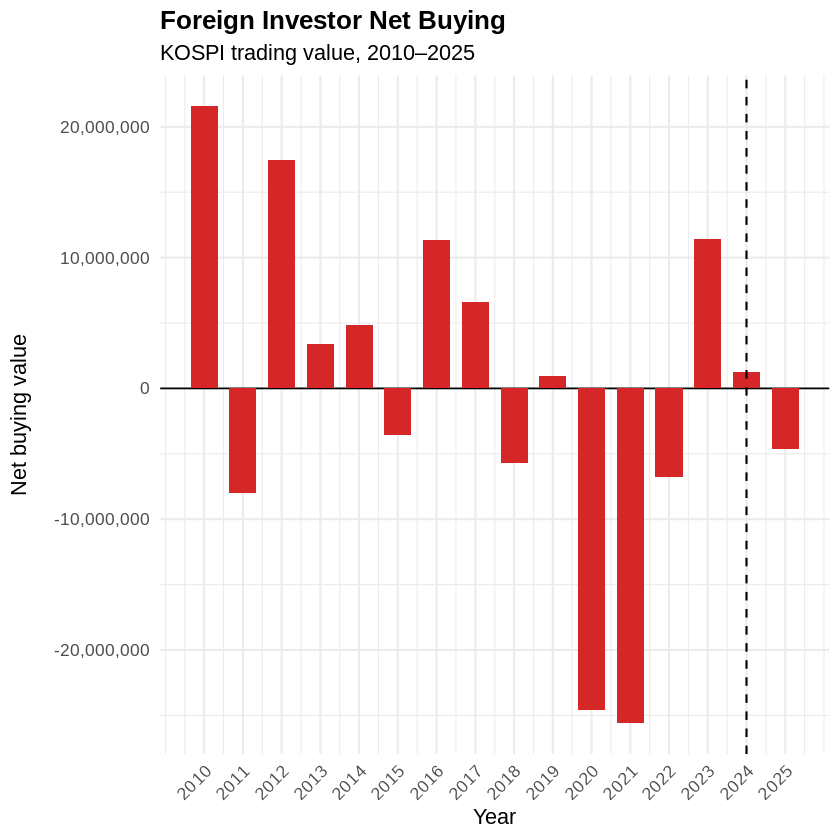

In [ ]:
ggplot(foreigners, aes(x = year, y = value_net_buying)) +
  geom_hline(yintercept = 0, linewidth = 0.5, color = "black") +
  geom_col(fill = investor_colors["Foreigners"], width = 0.7) +
  geom_vline(
    xintercept = 2024,
    linetype = "dashed",
    linewidth = 0.6,
    color = "black"
  ) +
  scale_y_continuous(labels = comma) +
  scale_x_continuous(breaks = seq(2010, 2025, 1)) +
  labs(
    title = "Foreign Investor Net Buying",
    subtitle = "KOSPI trading value, 2010–2025",
    x = "Year",
    y = "Net buying value",
    #caption = "Source: KRX investor trading data."
  ) +
  theme_minimal(base_size = 13, base_family = "sans") +
  theme(
    plot.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.caption = element_text(hjust = 0)
  )

In [ ]:
ggsave(
  filename = "graphs/foreign_investor_net_buying_2010_2025.png",
  width = 11,
  height = 6.5,
  dpi = 300
)

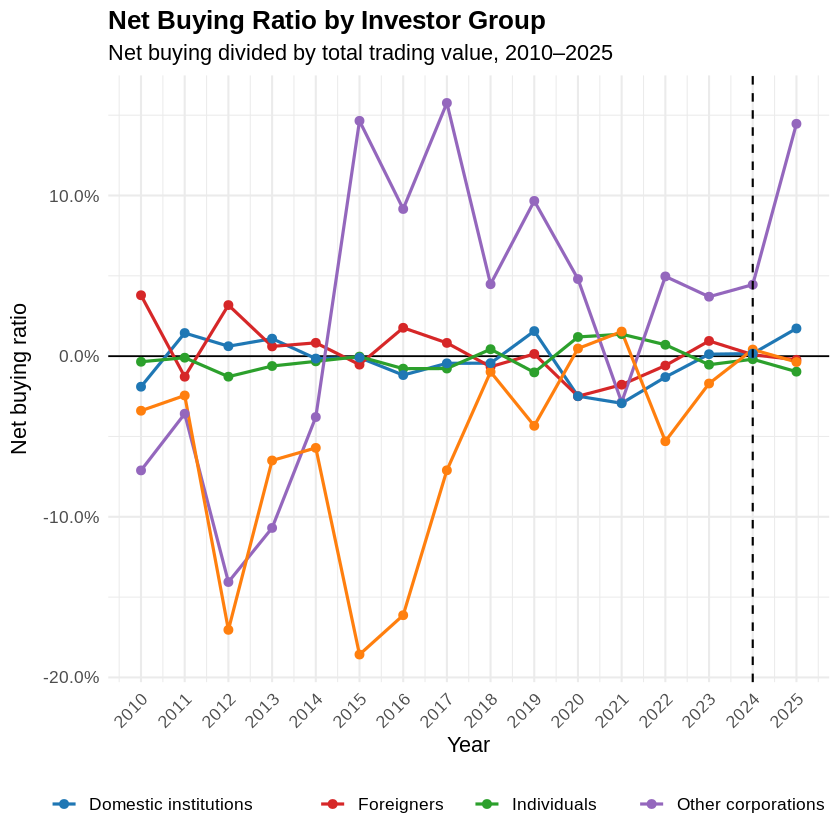

In [ ]:
ggplot(trading_main, aes(x = year, y = net_buying_ratio_value, color = investor_group_clean)) +
  geom_hline(yintercept = 0, linewidth = 0.5, color = "black") +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2) +
  geom_vline(
    xintercept = 2024,
    linetype = "dashed",
    linewidth = 0.6,
    color = "black"
  ) +
  scale_color_manual(values = investor_colors) +
  scale_y_continuous(labels = percent_format(accuracy = 0.1)) +
  scale_x_continuous(breaks = seq(2010, 2025, 1)) +
  labs(
    title = "Net Buying Ratio by Investor Group",
    subtitle = "Net buying divided by total trading value, 2010–2025",
    x = "Year",
    y = "Net buying ratio",
    color = "Investor group",
    #caption = "Source: KRX investor trading data."
  ) +
  theme_minimal(base_size = 13, base_family = "sans") +
  theme(
    legend.position = "bottom",
    plot.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.caption = element_text(hjust = 0)
  )

In [ ]:
ggsave(
  filename = "graphs/net_buying_ratio_by_investor_group_2010_2025.png",
  width = 12,
  height = 7,
  dpi = 300
)

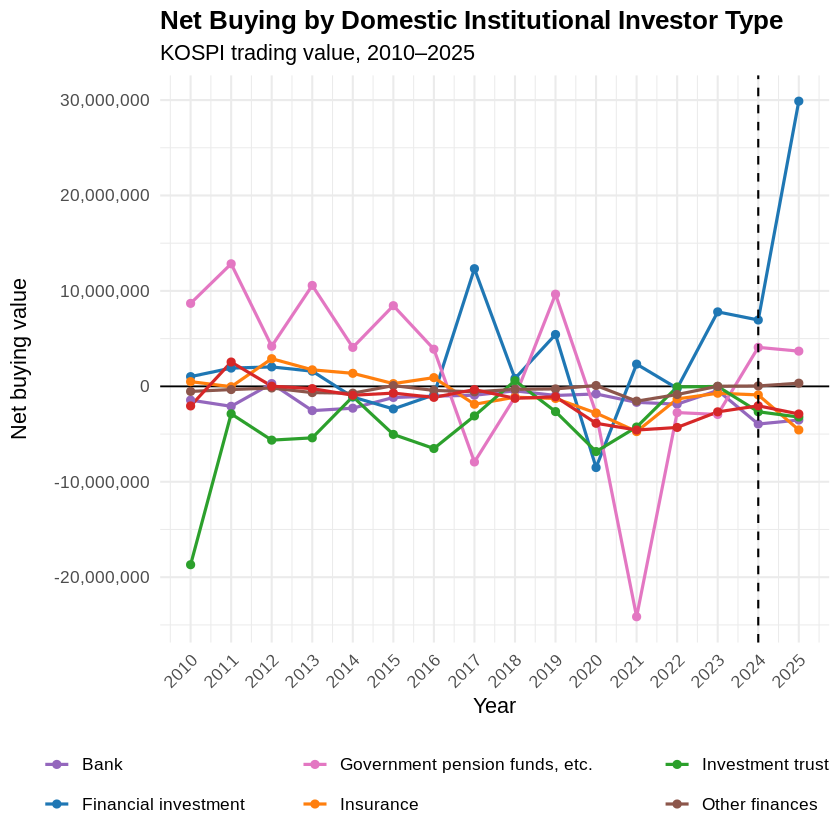

In [ ]:
ggplot(institutional_detail, aes(x = year, y = value_net_buying, color = investor_type)) +
  geom_hline(yintercept = 0, linewidth = 0.5, color = "black") +
  geom_line(linewidth = 0.9) +
  geom_point(size = 1.8) +
  geom_vline(
    xintercept = 2024,
    linetype = "dashed",
    linewidth = 0.6,
    color = "black"
  ) +
  scale_color_manual(values = institution_colors) +
  scale_y_continuous(labels = comma) +
  scale_x_continuous(breaks = seq(2010, 2025, 1)) +
  labs(
    title = "Net Buying by Domestic Institutional Investor Type",
    subtitle = "KOSPI trading value, 2010–2025",
    x = "Year",
    y = "Net buying value",
    color = "Investor type",
    #caption = "Source: KRX investor trading data."
  ) +
  theme_minimal(base_size = 13, base_family = "sans") +
  theme(
    legend.position = "bottom",
    plot.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.caption = element_text(hjust = 0)
  )

In [ ]:
ggsave(
  filename = "graphs/domestic_institutional_subtypes_net_buying_2010_2025.png",
  width = 13,
  height = 7,
  dpi = 300
)

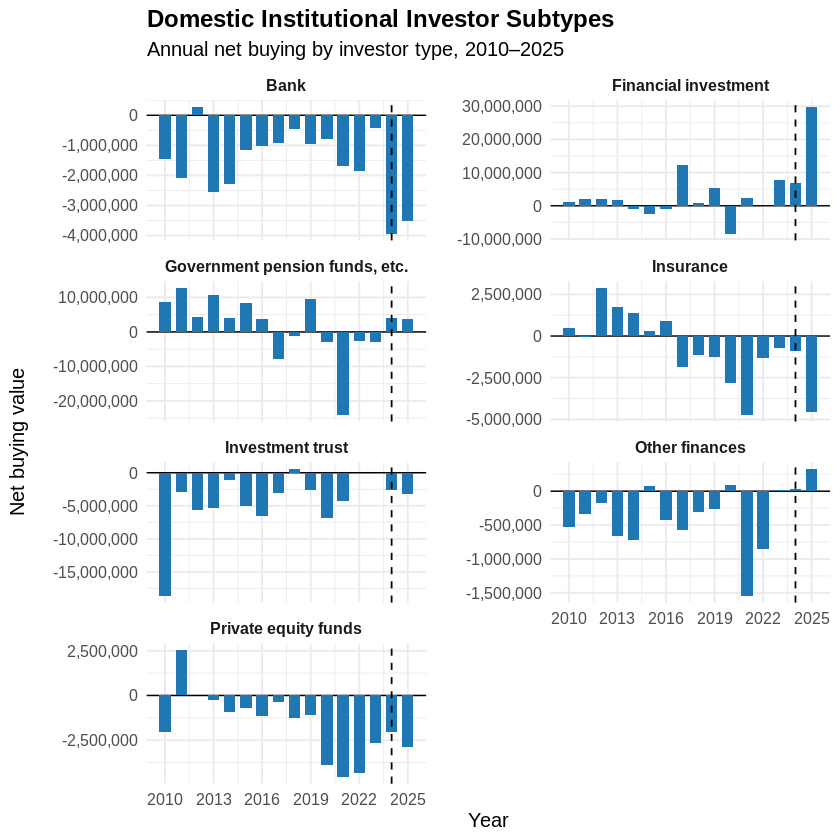

In [ ]:
ggplot(institutional_detail, aes(x = year, y = value_net_buying)) +
  geom_hline(yintercept = 0, linewidth = 0.4, color = "black") +
  geom_col(fill = "#1F77B4", width = 0.7) +
  geom_vline(
    xintercept = 2024,
    linetype = "dashed",
    linewidth = 0.5,
    color = "black"
  ) +
  facet_wrap(~ investor_type, scales = "free_y", ncol = 2) +
  scale_y_continuous(labels = comma) +
  scale_x_continuous(breaks = seq(2010, 2025, 3)) +
  labs(
    title = "Domestic Institutional Investor Subtypes",
    subtitle = "Annual net buying by investor type, 2010–2025",
    x = "Year",
    y = "Net buying value",
    #caption = "Source: KRX investor trading data."
  ) +
  theme_minimal(base_size = 12, base_family = "sans") +
  theme(
    plot.title = element_text(face = "bold"),
    plot.caption = element_text(hjust = 0),
    strip.text = element_text(face = "bold")
  )

In [ ]:
ggsave(
  filename = "graphs/domestic_institutional_subtypes_faceted_2010_2025.png",
  width = 13,
  height = 9,
  dpi = 300
)

In [ ]:
trading_activity_long <- trading_main %>%
  select(year, investor_group_clean, value_sell, value_buy) %>%
  pivot_longer(
    cols = c(value_sell, value_buy),
    names_to = "transaction_type",
    values_to = "value"
  ) %>%
  mutate(
    transaction_type = recode(
      transaction_type,
      "value_sell" = "Sell",
      "value_buy" = "Buy"
    )
  )

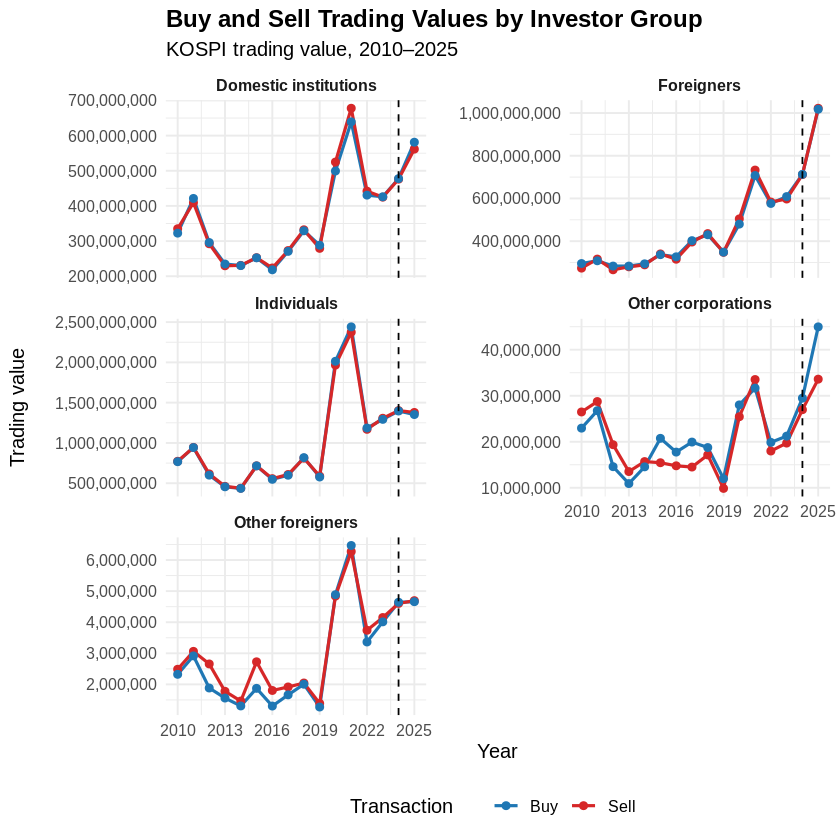

In [ ]:
ggplot(trading_activity_long, aes(x = year, y = value, color = transaction_type)) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 1.8) +
  facet_wrap(~ investor_group_clean, scales = "free_y", ncol = 2) +
  geom_vline(
    xintercept = 2024,
    linetype = "dashed",
    linewidth = 0.5,
    color = "black"
  ) +
  scale_y_continuous(labels = comma) +
  scale_x_continuous(breaks = seq(2010, 2025, 3)) +
  scale_color_manual(values = c("Buy" = "#1F77B4", "Sell" = "#D62728")) +
  labs(
    title = "Buy and Sell Trading Values by Investor Group",
    subtitle = "KOSPI trading value, 2010–2025",
    x = "Year",
    y = "Trading value",
    color = "Transaction",
    #caption = "Source: KRX investor trading data."
  ) +
  theme_minimal(base_size = 12, base_family = "sans") +
  theme(
    legend.position = "bottom",
    plot.title = element_text(face = "bold"),
    plot.caption = element_text(hjust = 0),
    strip.text = element_text(face = "bold")
  )

In [ ]:
ggsave(
  filename = "graphs/buy_sell_trading_values_by_investor_group_2010_2025.png",
  width = 13,
  height = 9,
  dpi = 300
)

In [ ]:
value_up_summary <- trading_main %>%
  mutate(
    value_up_period = if_else(year >= 2024, "Post-Value-Up", "Pre-Value-Up")
  ) %>%
  group_by(value_up_period, investor_group_clean) %>%
  summarise(
    mean_net_buying = mean(value_net_buying, na.rm = TRUE),
    .groups = "drop"
  )

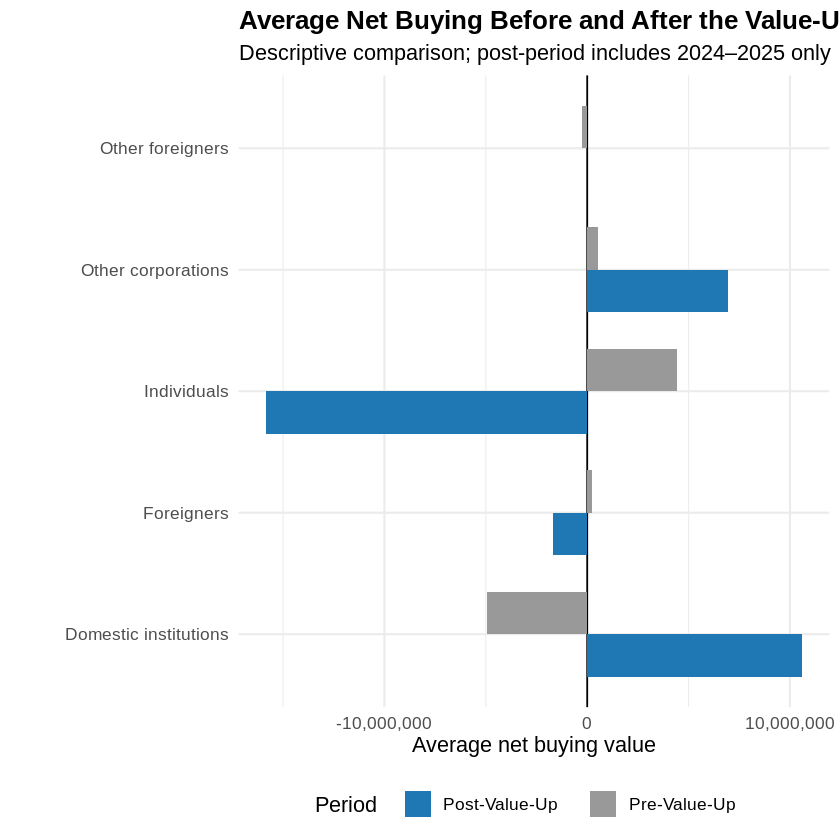

In [ ]:
ggplot(value_up_summary, aes(x = investor_group_clean, y = mean_net_buying, fill = value_up_period)) +
  geom_hline(yintercept = 0, linewidth = 0.5, color = "black") +
  geom_col(position = "dodge", width = 0.7) +
  coord_flip() +
  scale_y_continuous(labels = comma) +
  scale_fill_manual(values = c("Pre-Value-Up" = "grey60", "Post-Value-Up" = "#1F77B4")) +
  labs(
    title = "Average Net Buying Before and After the Value-Up Program",
    subtitle = "Descriptive comparison; post-period includes 2024–2025 only",
    x = NULL,
    y = "Average net buying value",
    fill = "Period",
    #caption = "Source: KRX investor trading data."
  ) +
  theme_minimal(base_size = 13, base_family = "sans") +
  theme(
    legend.position = "bottom",
    plot.title = element_text(face = "bold"),
    plot.caption = element_text(hjust = 0)
  )

In [ ]:
ggsave(
  filename = "graphs/pre_post_value_up_average_net_buying.png",
  width = 11,
  height = 6.5,
  dpi = 300
)

In [ ]:
kospi_yearly <- read_csv("kospi_yearly_2010_2025.csv")

glimpse(kospi_yearly)

Rows: 16 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (9): year, mean_close, year_end_close, mean_per, median_per, mean_pbr, m...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 16
Columns: 9
$ year                <dbl> 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 20…
$ mean_close          <dbl> 1764.994, 1983.420, 1930.373, 1960.500, 1982.158, …
$ year_end_close      <dbl> 2051.00, 1825.74, 1997.05, 2011.34, 1915.59, 1961.…
$ mean_per            <dbl> 18.29669, 13.64069, 12.25839, 13.45433, 15.29980, …
$ median_per          <dbl> 16.450, 12.705, 12.280, 13.200, 15.370, 15.840, 14…
$ mean_pbr            <dbl> 1.3317131, 1.3493548, 1.2255242, 1.1829150, 1.1447…
$ median_pbr          <dbl> 1.330, 1.380, 1.220, 1.190, 1.150, 1.130, 1.060, 1…
$ mean_dividend_yield <dbl> 1.235020, 1.337379, 1.406573, 1.244332, 1.123347, …
$ observations        <dbl> 251, 248, 248, 247, 245, 248, 246, 243, 244, 246, …


In [ ]:
investor_pbr <- trading_wide %>%
  left_join(
    kospi_yearly %>% select(year, mean_pbr),
    by = "year"
  )

In [ ]:
investor_pbr_indexed <- investor_pbr %>%
  select(year, domestic_institutions, foreigners, mean_pbr) %>%
  mutate(
    domestic_institutions_index = as.numeric(scale(domestic_institutions)),
    foreigners_index = as.numeric(scale(foreigners)),
    pbr_index = as.numeric(scale(mean_pbr))
  )

In [ ]:
investor_pbr_long <- investor_pbr_indexed %>%
  select(year, domestic_institutions_index, foreigners_index, pbr_index) %>%
  pivot_longer(
    cols = c(domestic_institutions_index, foreigners_index, pbr_index),
    names_to = "variable",
    values_to = "indexed_value"
  ) %>%
  mutate(
    variable = recode(
      variable,
      "domestic_institutions_index" = "Domestic institutions net buying",
      "foreigners_index" = "Foreigners net buying",
      "pbr_index" = "KOSPI P/B"
    )
  )

In [ ]:
indexed_colors <- c(
  "Domestic institutions net buying" = "#1F77B4",
  "Foreigners net buying" = "#D62728",
  "KOSPI P/B" = "black"
)

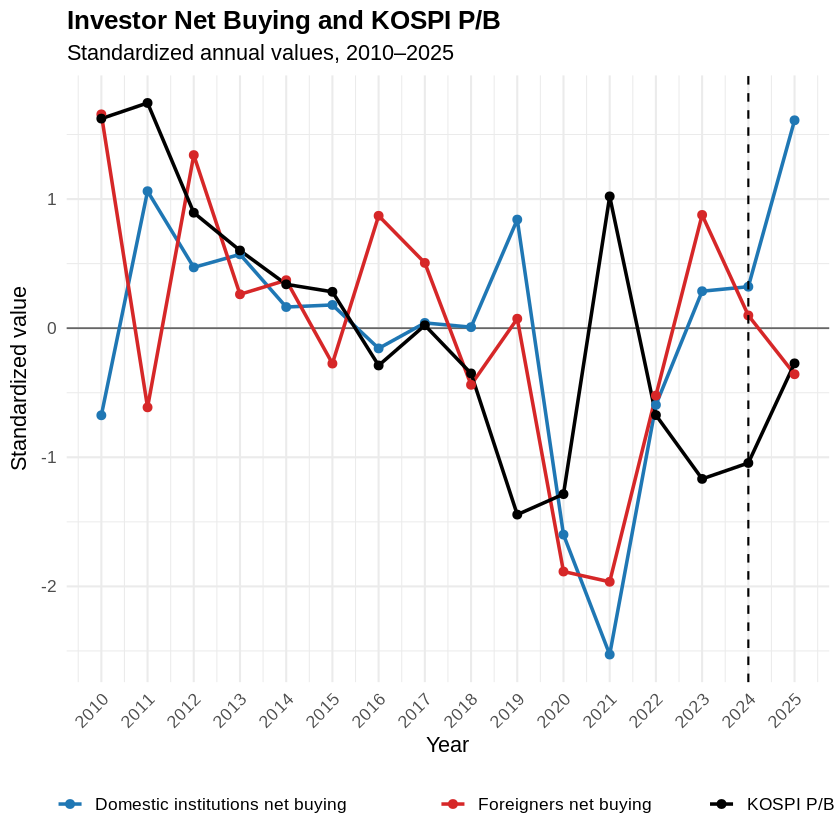

In [ ]:
ggplot(investor_pbr_long, aes(x = year, y = indexed_value, color = variable)) +
  geom_hline(yintercept = 0, linewidth = 0.5, color = "grey40") +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  geom_vline(
    xintercept = 2024,
    linetype = "dashed",
    linewidth = 0.6,
    color = "black"
  ) +
  scale_color_manual(values = indexed_colors) +
  scale_x_continuous(breaks = seq(2010, 2025, 1)) +
  labs(
    title = "Investor Net Buying and KOSPI P/B",
    subtitle = "Standardized annual values, 2010–2025",
    x = "Year",
    y = "Standardized value",
    color = NULL,
    #caption = "Sources: KRX investor trading data and KOSPI valuation data."
  ) +
  theme_minimal(base_size = 13, base_family = "sans") +
  theme(
    legend.position = "bottom",
    plot.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.caption = element_text(hjust = 0)
  )

In [ ]:
ggsave(
  filename = "graphs/investor_net_buying_and_kospi_pbr_indexed.png",
  width = 12,
  height = 7,
  dpi = 300
)